In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
import kagglehub

In [29]:
# Diabetes
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print(path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
/kaggle/input/pima-indians-diabetes-database


In [30]:
# Coleta de dados
df = pd.read_csv(f"{path}/diabetes.csv")

# Data cleaning and preparation
# Remoção de valores zerados
colums = ['SkinThickness', 'BloodPressure', 'BMI']
df = df[(df[colums] != 0).all(axis=1)]

x = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

In [31]:
# Separar os conjuntos de treinamento e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [32]:
# Função de regressão logística
def regressao(x_train, y_train, x_test, y_test):
  model = LogisticRegression(max_iter=1000)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  return y_pred

In [33]:
# Função para KNN
def knn(x_train, y_train, x_test, k):
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  return y_pred

In [34]:
# Função de árvore de decisão
def arvore(x_train, y_train, x_test, k):
  model = DecisionTreeClassifier(max_depth=k, random_state=42)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  return y_pred

In [35]:
# Função do Random Forest
def random_forest(x_train, y_train, x_test, n, k):
  model = RandomForestClassifier(n_estimators=n, max_depth=k, random_state=42)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  return y_pred

In [36]:
# Função para Gradient Boosting
def gradient_boosting(x_train, y_train, x_test):
  model = GradientBoostingClassifier(n_estimators=50,  # numero de arvores
                                     learning_rate=0.1, # taxa de aprendizado
                                     max_depth=3,       # profundidade das arvores
                                     random_state=42)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  return y_pred

In [37]:
# Metricas de avaliação
y_regressao = regressao(x_train, y_train, x_test, y_test)
acuracia_regressao = accuracy_score(y_test, y_regressao)

y_knn = knn(x_train, y_train, x_test, k=9)
acuracia_knn = accuracy_score(y_test, y_knn)

y_arvore = arvore(x_train, y_train, x_test, k=8)
acuracia_arvore = accuracy_score(y_test, y_arvore)

y_random_forest = random_forest(x_train, y_train, x_test, 100, 8)
acuracia_random_forest = accuracy_score(y_test, y_random_forest)

print(f"Acurácia da Regressão Logística: \t {acuracia_regressao:.2f}")
print(f"Acurácia do KNN: \t\t\t {acuracia_knn:.2f}")
print(f"Acurácia da Árvore de Decisão: \t\t {acuracia_arvore:.2f}")
print(f"Acurácia do Random Forest: \t\t {acuracia_random_forest:.2f}")

Acurácia da Regressão Logística: 	 0.78
Acurácia do KNN: 			 0.70
Acurácia da Árvore de Decisão: 		 0.67
Acurácia do Random Forest: 		 0.70


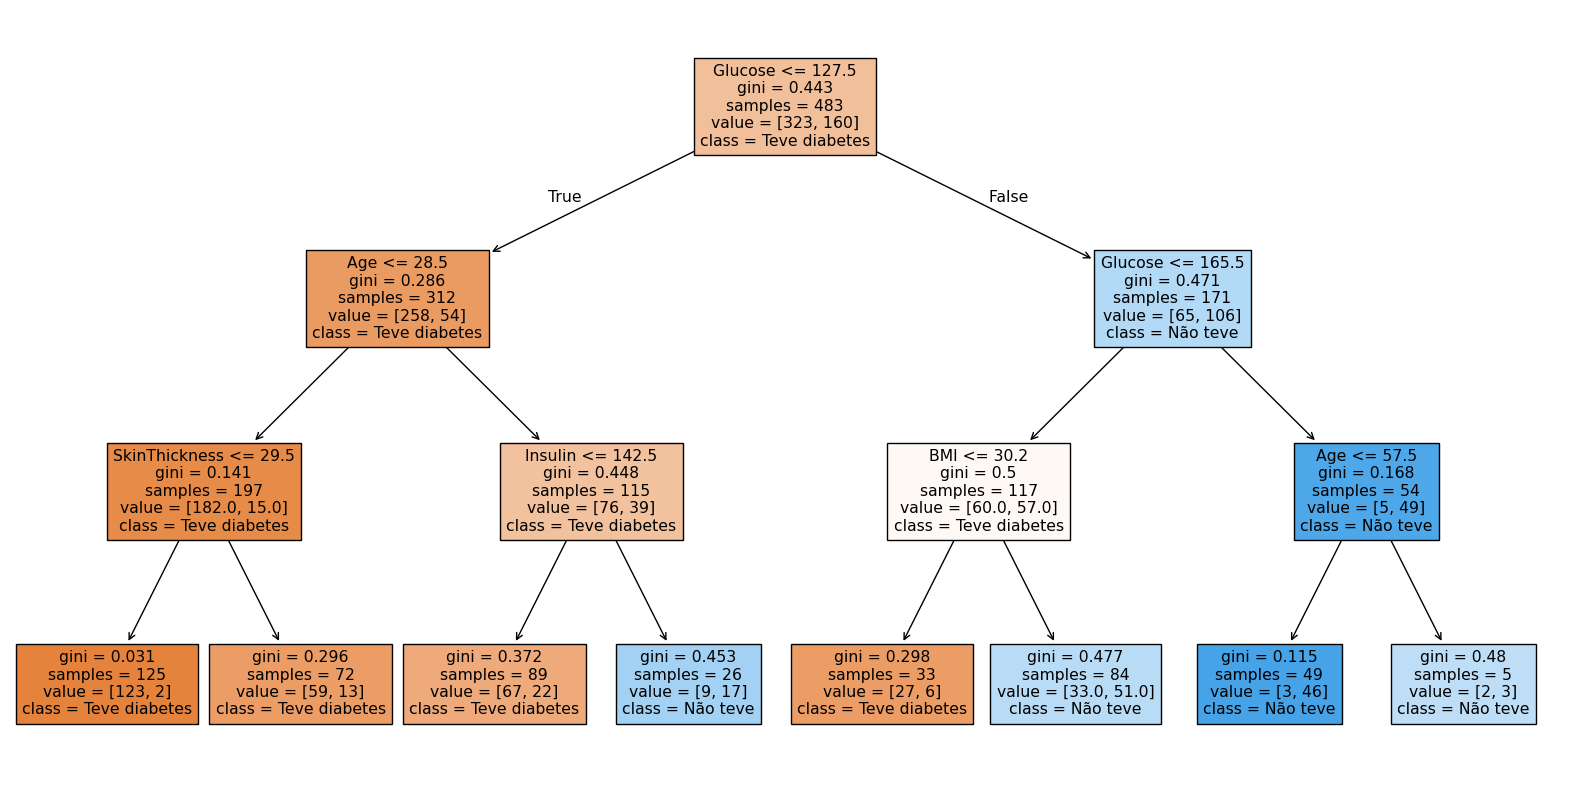

In [38]:
# Plotagem da árvore de decisão
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(x_train, y_train)
plt.figure(figsize=(20, 10))
plot_tree(model, filled=True, feature_names=x.columns, class_names=['Teve diabetes', 'Não teve'])
plt.show()

In [39]:
# GridSearch
# Instanciar o modelo
model = RandomForestClassifier(random_state=42)

params_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar o Grid Search
grid_search = GridSearchCV(model, params_grid, cv=5, scoring='accuracy', verbose=4)
grid_search.fit(x_train, y_train)

# Melhores parâmetros
print(f"\nMelhores parâmetros: \t {grid_search.best_params_}")
print(f"Melhor acurácia: \t {grid_search.best_score_}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.763 total time=   0.1s
[CV 2/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.763 total time=   0.1s
[CV 3/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.784 total time=   0.1s
[CV 4/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.802 total time=   0.1s
[CV 5/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.802 total time=   0.1s
[CV 1/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.784 total time=   0.2s
[CV 2/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.742 total time=   0.2s
[CV 3/5] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.784 t

In [40]:
# RandomizedSearch
# Instanciar o modelo
model = RandomForestClassifier(random_state=42)

params_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar o Grid Search
grid_search = RandomizedSearchCV(model, params_grid, cv=5, scoring='accuracy', verbose=4)
grid_search.fit(x_train, y_train)

# Melhores parâmetros
print(f"\nMelhores parâmetros: \t {grid_search.best_params_}")
print(f"Melhor acurácia: \t {grid_search.best_score_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100;, score=0.784 total time=   0.2s
[CV 2/5] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100;, score=0.753 total time=   0.2s
[CV 3/5] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100;, score=0.784 total time=   0.2s
[CV 4/5] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100;, score=0.812 total time=   0.2s
[CV 5/5] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100;, score=0.750 total time=   0.2s
[CV 1/5] END max_depth=None, min_samples_leaf=4, min_samples_split=5, n_estimators=200;, score=0.794 total time=   0.4s
[CV 2/5] END max_depth=None, min_samples_leaf=4, min_samples_split=5, n_estimators=200;, score=0.763 total time=   0.4s
[CV 3/5] END max_depth=None, min_samples_leaf=4, min_samples_split=5, n_estimators=200;, score=0.784 total time=  

In [41]:
# RandomizedSearchCV
# Instanciar o modelo
model = GradientBoostingClassifier(random_state=42)

params_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar o Grid Search
grid_search = RandomizedSearchCV(model, params_grid, cv=5, scoring='accuracy', verbose=4)
grid_search.fit(x_train, y_train)

# Melhores parâmetros
print(f"\nMelhores parâmetros: \t {grid_search.best_params_}")
print(f"Melhor acurácia: \t {grid_search.best_score_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END max_depth=3, min_samples_leaf=2, min_samples_split=10, n_estimators=50;, score=0.835 total time=   0.1s
[CV 2/5] END max_depth=3, min_samples_leaf=2, min_samples_split=10, n_estimators=50;, score=0.773 total time=   0.1s
[CV 3/5] END max_depth=3, min_samples_leaf=2, min_samples_split=10, n_estimators=50;, score=0.773 total time=   0.1s
[CV 4/5] END max_depth=3, min_samples_leaf=2, min_samples_split=10, n_estimators=50;, score=0.802 total time=   0.1s
[CV 5/5] END max_depth=3, min_samples_leaf=2, min_samples_split=10, n_estimators=50;, score=0.802 total time=   0.1s
[CV 1/5] END max_depth=7, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.794 total time=   0.3s
[CV 2/5] END max_depth=7, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.680 total time=   0.3s
[CV 3/5] END max_depth=7, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=0.763 total time=   0.3s
[CV 4/